# Energy usage analysis 

In [25]:
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

from pandas import DataFrame

from easyvvuq.analysis.sc_analysis import SCAnalysisResults

from typing import cast

import machines
import programs
import scenarios.main.energyuq as energyuq

### Restore data from most recent run 

In [26]:
campaign_name = "energy"
campaign, analysis = energyuq.load(programs.FFT, machines.Glados, campaign_name)

sampler = energyuq.get_sampler(campaign)
qoi_cols = analysis.qoi_cols
qoi = "energy_uj"
results = cast(SCAnalysisResults, campaign.get_last_analysis()) # better linting


### Define some of the plotting functions

In [27]:
def plot_grid_2D():

    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel("Configurations chosen")
    
    ax=[]
    ic=0
    for i in range(L-1):
        xd = values[ic*2].upper[0] - values[ic*2].lower[0]
        yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
        ax.append(fig.add_subplot(R, C, ic+1,
                                  xlim=[values[ic*2].lower[0] - xd/10, values[ic*2].upper[0] + xd/10],
                                  ylim=[values[ic*2+1].lower[0] - yd/10, values[ic*2+1].upper[0] + yd/10], 
                                  xlabel=labels[ic*2], ylabel=labels[ic*2+1])
                 )
        ic += 1

    xd = values[ic*2].upper[0] - values[ic*2].lower[0]
    yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
    ax.append(fig.add_subplot(R, C, ic+1,
                              xlim=[values[-2].lower[0] - xd/10, values[-2].upper[0] + xd/10], 
                              ylim=[values[-1].lower[0] - yd/10, values[-1].upper[0] + yd/10], 
                              xlabel=labels[-2], ylabel=labels[-1])
             )

    accepted_grid = sampler.generate_grid(analysis.l_norm)

    ic=0
    for i in range(L-1):
        ax[i].plot(accepted_grid[:,ic*2], accepted_grid[:,ic*2+1], 'o', alpha=0.25)
        ic += 1
    ax[-1].plot(accepted_grid[:,-2], accepted_grid[:,-1], 'o', alpha=0.25)
    # plt.tight_layout()
    
def plot_sorted(dataframe, qoi=qoi):
    ### por que eres assim???????
    column_key = (qoi, 0)
    sorted_dataframe: DataFrame = dataframe.sort_values(by=column_key, ascending=False)

    plt.semilogy(sorted_dataframe[column_key].to_numpy())
    plt.title(f"{qoi} sorted")
    plt.show()

def get_confidence_intervals(samples, conf=0.9):
    """
    Compute the confidence intervals given an array of samples

    Parameters
    ----------
    samples : array
        Samples on which to compute the intervals.
    conf : float, optional, must be in [0, 1].
        The confidence interval percentage. The default is 0.9.

    Returns
    -------
    lower : array
        The lower confidence bound..
    upper : array
        The upper confidence bound.

    """

    # ake sure conf is in [0, 1]
    if conf < 0.0 or conf > 1.0:
        print('conf must be specified within [0, 1]')
        return

    # lower bound = alpha, upper bound = 1 - alpha
    alpha = 0.5 * (1.0 - conf)

    # arrays for lower and upper bound of the interval
    n_samples = samples.shape[0]
    N_qoi = samples.shape[1]
    lower = np.zeros(N_qoi)
    upper = np.zeros(N_qoi)

    # the probabilities of the ecdf
    prob = np.linspace(0, 1, n_samples)
    # the closest locations in prob that correspond to the interval bounds
    idx0 = np.where(prob <= alpha)[0][-1]
    idx1 = np.where(prob <= 1.0 - alpha)[0][-1]

    # for every location of qoi compute the ecdf-based confidence interval
    for i in range(N_qoi):
        # the sorted surrogate samples at the current location
        samples_sorted = np.sort(samples[:, i])
        # the corresponding confidence interval
        lower[i] = samples_sorted[idx0]
        upper[i] = samples_sorted[idx1]

    return lower, upper

def plot_sobols1(qoi):
    inputs = list(sampler.vary.get_keys())
    d = len(inputs)
    
    fig = plt.figure(layout="constrained")
    ax = fig.add_subplot(111, title=r'First-order Sobol indices', ylim=[0,1])
    ax.set_ylabel(r'$S_i$', fontsize=14)
    
    sobols_first = np.array(list(results.sobols_first(qoi).values()))
    ax.bar(0, np.sum(sobols_first), color='salmon')
    ax.bar(np.arange(1, d+1), sobols_first.flatten(), color='dodgerblue')

    labels = ['Total first order']
    for i in range(d): labels.append(inputs[i])
    ax.set_xticks(np.arange(d+1))
    ax.set_xticklabels(labels, rotation=90)

def plot_grid_2D_best(qoi=qoi):

    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"Configurations evaluated by {qoi}")

    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i*2].upper[0] - values[i*2].lower[0]
        yd = values[i*2+1].upper[0] - values[i*2+1].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i*2].lower[0] - xd/10, values[i*2].upper[0] + xd/10],
                                  ylim=[values[i*2+1].lower[0] - yd/10, values[i*2+1].upper[0] + yd/10], 
                                  xlabel=labels[i*2], ylabel=labels[i*2+1])
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    dataframe = campaign.get_collation_result()
    ### por que eres assim???????
    column_key = (qoi, 0)
    dataframe: DataFrame = dataframe.sort_values(by=column_key, ascending=False)
    
    dataframe[f"{qoi}_norm"] = ((column := dataframe[qoi]) - column.min()) / (column.max() - column.min())

    s = dataframe[f"{qoi}_norm"].size

    colors = [ (y, (i / s), (1 - y), 1) for i, y in enumerate(dataframe[f"{qoi}_norm"].to_numpy())]


    more_red = Line2D([0], [0], color='red', lw=2, marker="o", linestyle='')
    more_blue = Line2D([0], [0], color='blue', lw=2, marker="o", linestyle='')
    more_cyan = Line2D([0], [0], color='cyan', lw=2, marker="o", linestyle='')
    legend_handles = [more_red, more_blue, more_cyan]
    legend_labels = ["Higher energy use", "Lesser energy use", "Among the best when ordered"]

    for i in range(L):
        xs = dataframe[(labels[i*2], 0)].to_numpy()
        ys = dataframe[(labels[i*2 + 1], 0)].to_numpy()
        ax[i].legend(handles=legend_handles, labels=legend_labels, draggable=True, fontsize='x-small', ncols=2, loc='upper center')
        ax[i].scatter(xs, ys, c=colors)
    
    # plt.tight_layout()

def plot_2D_single_dimension(qoi=qoi):
    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"For {qoi}")

    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper[0] - values[i].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower[0] - xd/10, values[i].upper[0] + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i].interpret_as_integer))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    dataframe = campaign.get_collation_result()

    for i in range(L):
        ax[i].scatter(dataframe[labels[i], 0], dataframe[qoi, 0])
    
    # plt.tight_layout()

def plot_boxplot(qoi=qoi):
    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"For {qoi}")
    
    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper[0] - values[i].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower[0] - xd/10, values[i].upper[0] + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i].interpret_as_integer))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    dataframe = campaign.get_collation_result()

    # make data:
    np.random.seed(10)
    D = np.random.normal((3, 5, 4), (1.25, 1.00, 1.25), (100, 3))

    for i in range(L):
        qoi_c = (qoi, 0)
        label_c = (labels[i], 0)
        box_frame = dataframe[[qoi_c, label_c]].groupby(by=label_c)[[qoi_c]].apply(lambda x: x[qoi_c].to_numpy()) # pyright: ignore[reportArgumentType, reportCallIssue]

        VP = ax[i].boxplot(box_frame.to_numpy(),
                            positions=box_frame.index.to_numpy(),
                            patch_artist=True,
                            showmeans=False, showfliers=False, manage_ticks = False,
                            medianprops={"color": "white", "linewidth": 0.5},
                            boxprops={"facecolor": "C0", "edgecolor": "white", "linewidth": 0.5},
                            whiskerprops={"color": "C0", "linewidth": 1.5},
                            capprops={"color": "C0", "linewidth": 1.5}
                        )

    # plt.tight_layout()

## Plots

1. Which points were chosen and ran

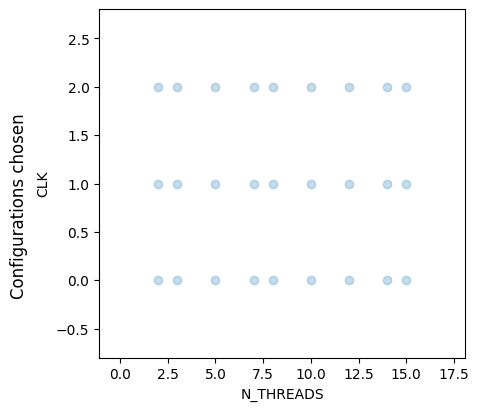

In [28]:
plot_grid_2D()

2. Which configurations consumed less energy in total

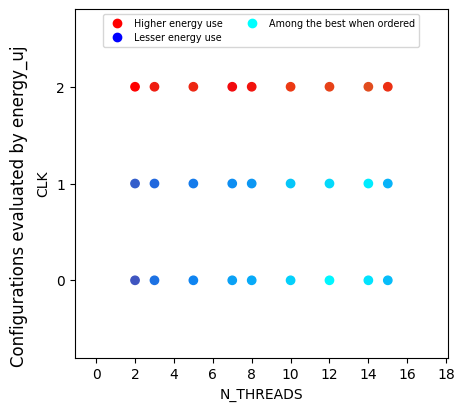

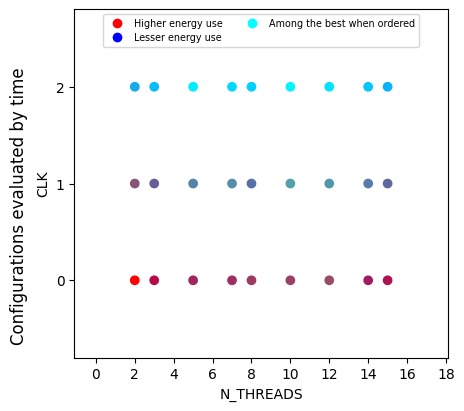

In [29]:
plot_grid_2D_best(qoi)
plot_grid_2D_best("time")

3. What is the difference between the best and worst configurations?

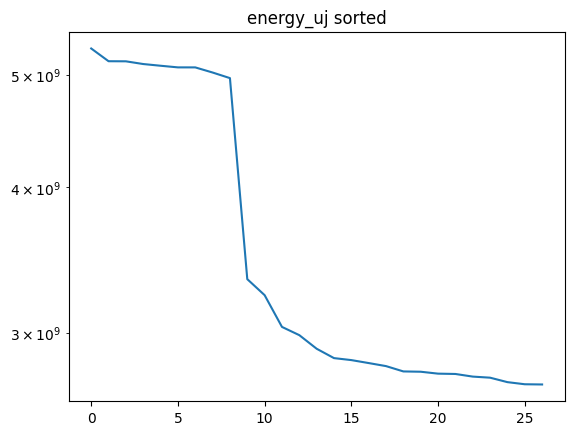

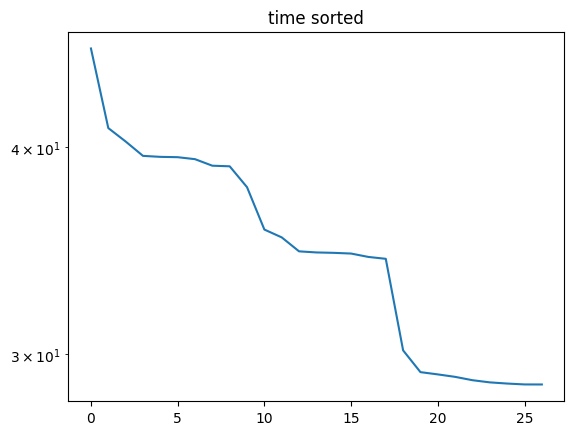

In [30]:
plot_sorted(campaign.get_collation_result(), qoi)
plot_sorted(campaign.get_collation_result(), "time")

4. View of the resulting energy usage against each parameter

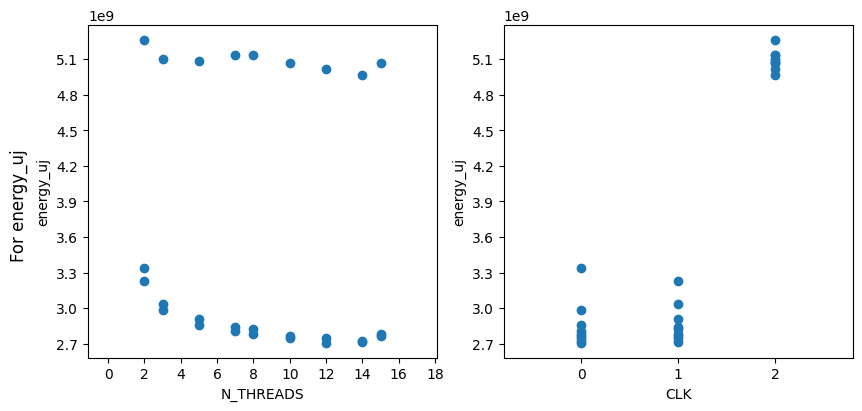

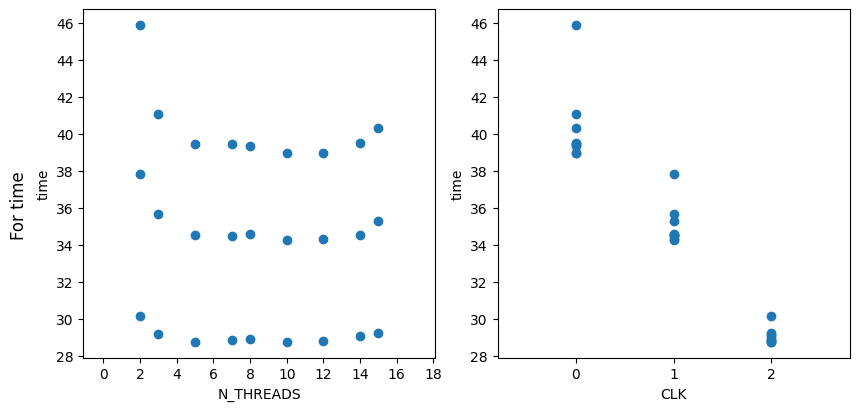

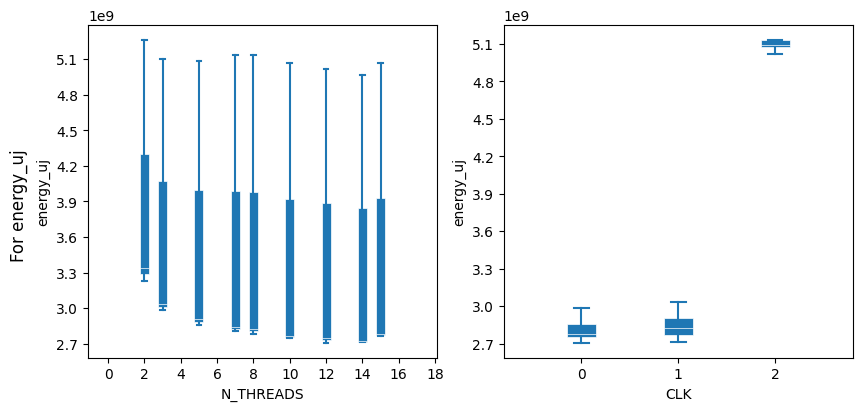

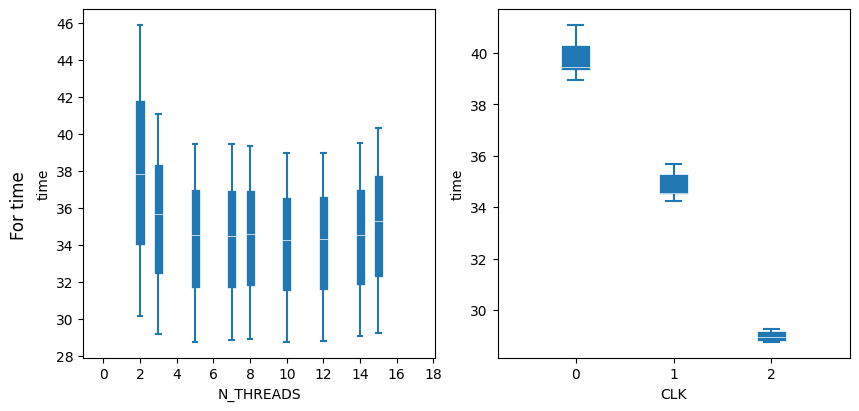

In [31]:
plot_2D_single_dimension(qoi)
plot_2D_single_dimension("time")
plot_boxplot(qoi)
plot_boxplot("time")

5. First order sobol indices and decomposition treemap

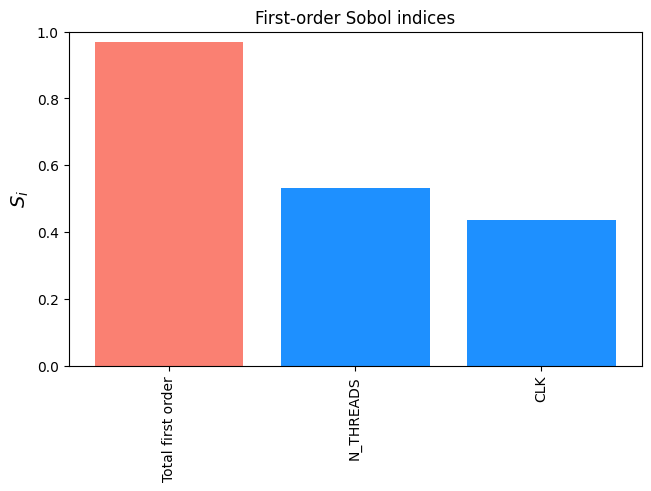

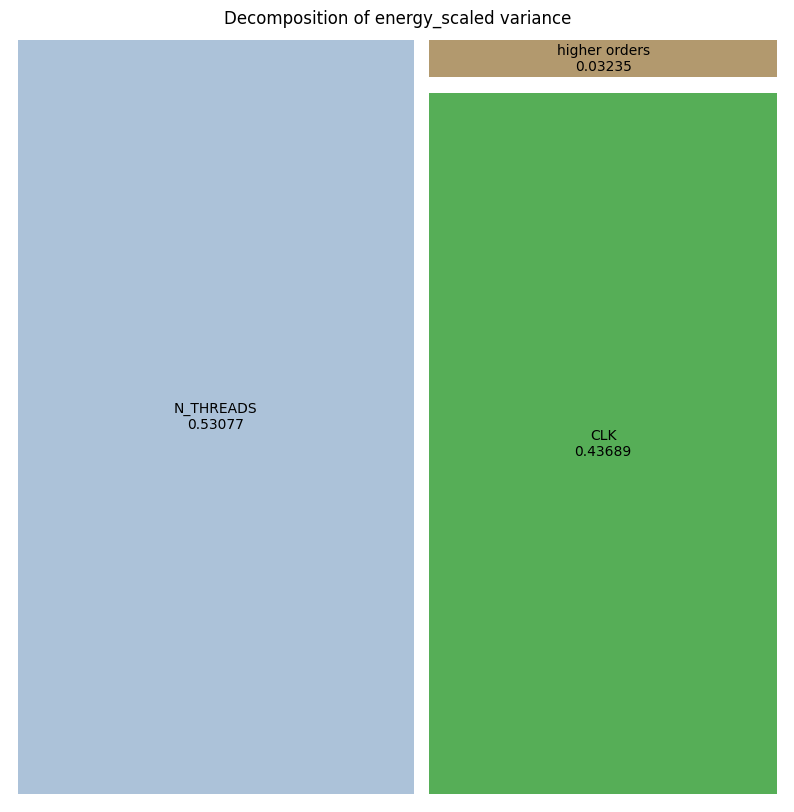

In [32]:
for qoi in qoi_cols:
    plot_sobols1(qoi)
    results.plot_sobols_treemap(qoi, figsize=(10, 10))
    plt.axis('off')

6. Adaptation table, histogram and errors

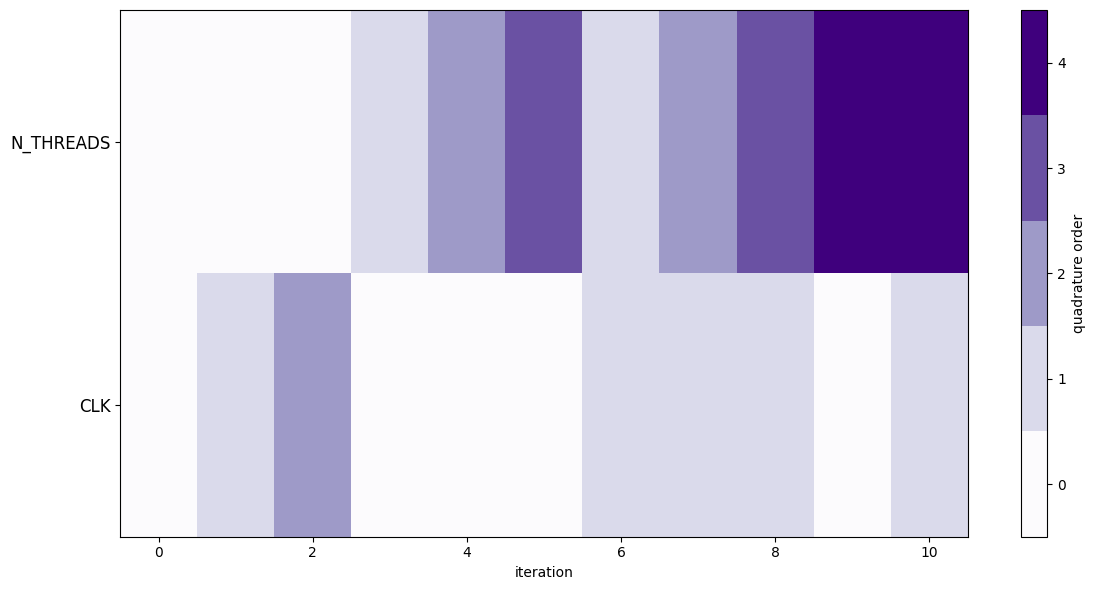

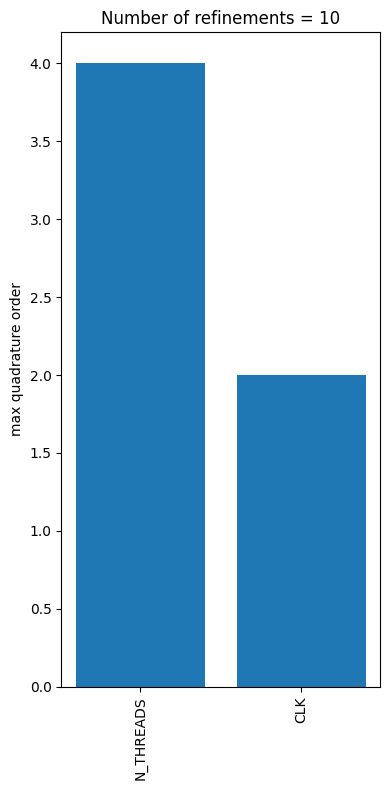

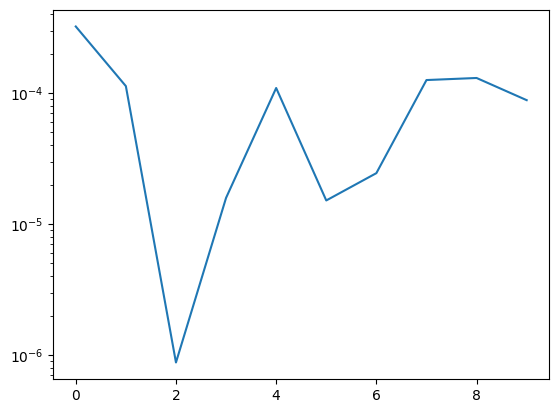

In [33]:
analysis.adaptation_table()
analysis.adaptation_histogram()
plt.semilogy(analysis.get_adaptation_errors())

7. Uncertainty amplification and stat convergence

-----------------
Mean CV input = 67.9411 %
Mean CV output = 29.2580 %
Uncertainty amplification factor = 0.2926/0.6794 = 0.4306
-----------------


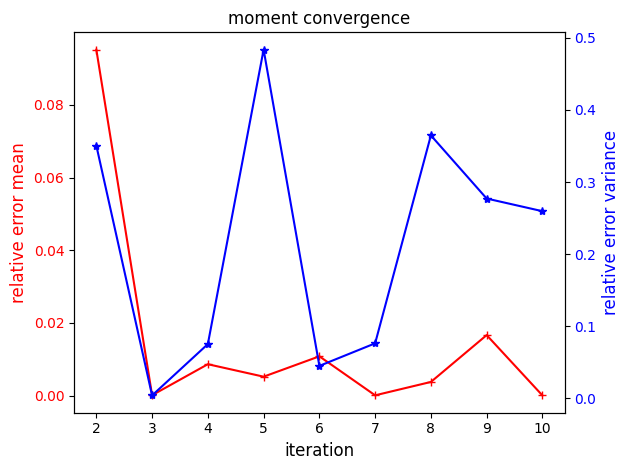

In [34]:
analysis.get_uncertainty_amplification(qoi)
analysis.plot_stat_convergence()